In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models

import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

2025-08-04 22:59:59.174061: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-04 22:59:59.196127: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9360] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-04 22:59:59.196160: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-04 22:59:59.196179: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1537] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-04 22:59:59.201540: I tensorflow/core/platform/cpu_feature_g

In [ ]:
# Configuration
NUM_CLASSES = 28  # 26 letters + space + nothing
GLOBAL_SEED = 420

# Import data loading functions
from asl_classifier.data import load_asl_data, get_class_names, preprocess_datasets

# Load and preprocess data
data_path = "../data/raw/ASL_Alphabet_Dataset/asl_alphabet_train"
train_ds, val_ds = load_asl_data(
    data_path=data_path,
    batch_size=32,
    validation_split=0.2,
    seed=GLOBAL_SEED
)

train_ds, val_ds = preprocess_datasets(train_ds, val_ds, 1000)

# Get class names
class_names = get_class_names(data_path)

print("✓ Data loaded and preprocessed")
print(f"Training batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Classes: {len(class_names)} - {class_names}")

## Baseline Model

We start with a simple CNN architecture to establish baseline performance and validate our approach.

In [3]:
# Simple baseline CNN architecture
baseline_model = models.Sequential([
    # Feature extraction layers
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Classification layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Baseline Model Architecture:")
baseline_model.summary()

Baseline Model Architecture:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 198, 198, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 99, 99, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 97, 97, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 48, 48, 32)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 73728)             0         
                                                                 
 dense (Dense)             

In [ ]:
# Train baseline model
print("Training baseline model...")

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

print("✓ Baseline training complete")

Training baseline model...
Epoch 1/10


2025-08-04 23:03:39.796765: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 517 of 1000
2025-08-04 23:03:48.112018: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.
2025-08-04 23:03:48.112018: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.
2025-08-04 23:03:59.804148: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 731 of 1000
2025-08-04 23:03:59.804148: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 731 of 1000
2025-08-04 23:04:04.710970: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.
2025-08-04 23:04:04.757204: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907
2025-08-04 23:04:04.710970: I tensorflow/core

5406/5406 [==============================] - 143s 20ms/step - loss: 3.3238 - accuracy: 0.0379 - val_loss: 3.3231 - val_accuracy: 0.0384
Epoch 2/10
5406/5406 [==============================] - 143s 20ms/step - loss: 3.3238 - accuracy: 0.0379 - val_loss: 3.3231 - val_accuracy: 0.0384
Epoch 2/10


2025-08-04 23:06:02.762095: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 592 of 1000
2025-08-04 23:06:09.354203: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.
2025-08-04 23:06:09.354203: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.
2025-08-04 23:06:12.764861: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 298 of 1000
2025-08-04 23:06:12.764861: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 298 of 1000


   7/5406 [..............................] - ETA: 1:51 - loss: 3.3253 - accuracy: 0.0491    

2025-08-04 23:06:24.173592: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


2149/5406 [==========>...................] - ETA: 59s - loss: 3.3232 - accuracy: 0.0394

NameError: name 'baseline_history' is not defined

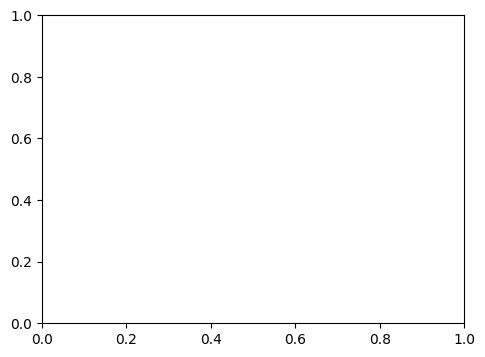

In [ ]:
# Visualize baseline model performance
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['accuracy'], label='Training', linewidth=2)
plt.plot(baseline_history.history['val_accuracy'], label='Validation', linewidth=2)
plt.title('Baseline Model - Accuracy', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['loss'], label='Training', linewidth=2)
plt.plot(baseline_history.history['val_loss'], label='Validation', linewidth=2)
plt.title('Baseline Model - Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_acc = baseline_history.history['val_accuracy'][-1]
print(f"Baseline Model Final Validation Accuracy: {final_acc:.4f}")